In [1]:
#Install Library
!pip install nltk         #NLTK (Natural Language Toolkit) is used to help the computer understand and process text data

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
#Upload dataset
from google.colab import files
uploaded = files.upload()

Saving spam_ham_dataset.csv to spam_ham_dataset.csv


In [6]:
#Load Dataset
df = pd.read_csv("spam_ham_dataset.csv")

df = df[['label', 'text']]          #Keep only needed columns
df.columns = ['label', 'message']   #Rename column (label->spam/ham, message->email text)

#Convert labels(ham->0, spam->1)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.head())

   label                                            message
0      0  Subject: enron methanol ; meter # : 988291\r\n...
1      0  Subject: hpl nom for january 9 , 2001\r\n( see...
2      0  Subject: neon retreat\r\nho ho ho , we ' re ar...
3      1  Subject: photoshop , windows , office . cheap ...
4      0  Subject: re : indian springs\r\nthis deal is t...


Class Distribution:
 label
0    3672
1    1499
Name: count, dtype: int64


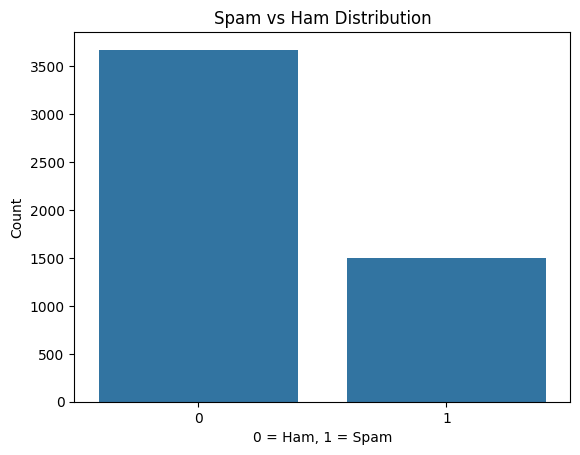

In [7]:
#EDA(Exploratory Data Analysis)
print("Class Distribution:\n", df['label'].value_counts())

sns.countplot(x='label', data=df)    #Draw graph
#Display graph
plt.title("Spam vs Ham Distribution")
plt.xlabel("0 = Ham, 1 = Spam")
plt.ylabel("Count")
plt.show()

In [8]:
#Data Cleaning
df.drop_duplicates(inplace=True)     #Remove duplicate emails

print("Missing values:\n",
df.isnull().sum())     #Check missing value

Missing values:
 label      0
message    0
dtype: int64


In [9]:
#Text Preprocessing
def clean_text(text):                  #Create function
    text = text.lower()                #Make text lowercase
    text = re.sub('[^a-z]', ' ', text) #Remove numbers & symbols
    words = text.split()               #Split sentence → words
    words = [w for w in words if w not in stopwords.words('english')]  #Remove Stopwords
    return ' '.join(words)

df['message'] = df['message'].apply(clean_text)

In [10]:
#Convert Text -> Numbers (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['message']).toarray()
y = df['label']

In [11]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
#Model1 -- Naive Bayes
nb_model = MultinomialNB()  #Create model
nb_model.fit(X_train, y_train)  #Train model

y_pred_nb = nb_model.predict(X_test)  #Predict results

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb)) #Show precision, recall, F1

acc_nb = accuracy_score(y_test, y_pred_nb)  #Calculate accuracy
print("Accuracy:", acc_nb)

Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       732
           1       0.91      0.95      0.93       267

    accuracy                           0.96       999
   macro avg       0.95      0.96      0.95       999
weighted avg       0.96      0.96      0.96       999

Accuracy: 0.960960960960961


In [13]:
#Model2 -- SVM
svm_model = SVC(kernel='linear', probability=True)  #Create SVM model
svm_model.fit(X_train, y_train) #Train model

y_pred_svm = svm_model.predict(X_test)  #predict

print("SVM Results:")
print(classification_report(y_test, y_pred_svm))

acc_svm = accuracy_score(y_test, y_pred_svm)  #Accuracy
print("Accuracy:", acc_svm)

SVM Results:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       732
           1       0.96      0.98      0.97       267

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.98      0.98      0.98       999

Accuracy: 0.982982982982983


In [ ]:
#Model3 -- Random Forest
rf_model = RandomForestClassifier(n_estimators=100) #Create model with 100 trees
rf_model.fit(X_train, y_train)  #Train

y_pred_rf = rf_model.predict(X_test)  #predict

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

acc_rf = accuracy_score(y_test, y_pred_rf)  #Accuracy
print("Accuracy:", acc_rf)

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       732
           1       0.93      0.97      0.95       267

    accuracy                           0.97       999
   macro avg       0.96      0.97      0.96       999
weighted avg       0.97      0.97      0.97       999

Accuracy: 0.9719719719719719


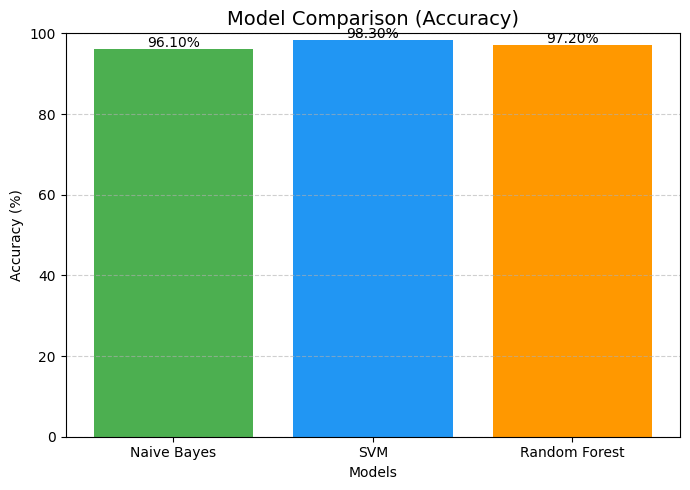

In [ ]:
#Compare models
import matplotlib.pyplot as plt

#Store results (percentage)
models = ['Naive Bayes', 'SVM', 'Random Forest']
accuracy = [acc_nb * 100, acc_svm * 100, acc_rf * 100]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracy, color=['#4CAF50', '#2196F3', '#FF9800']) #Create bar chart

plt.title("Model Comparison (Accuracy)", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

# Add value labels on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval:.2f}%', ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

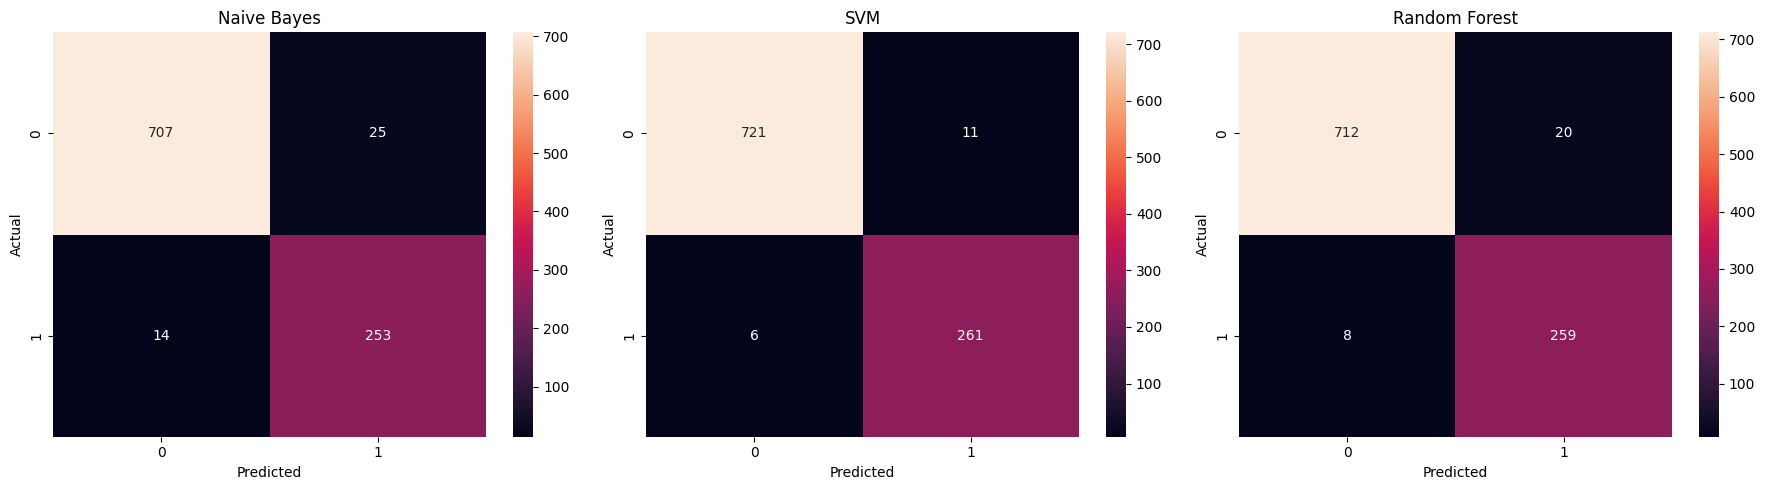

In [ ]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("Random Forest")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

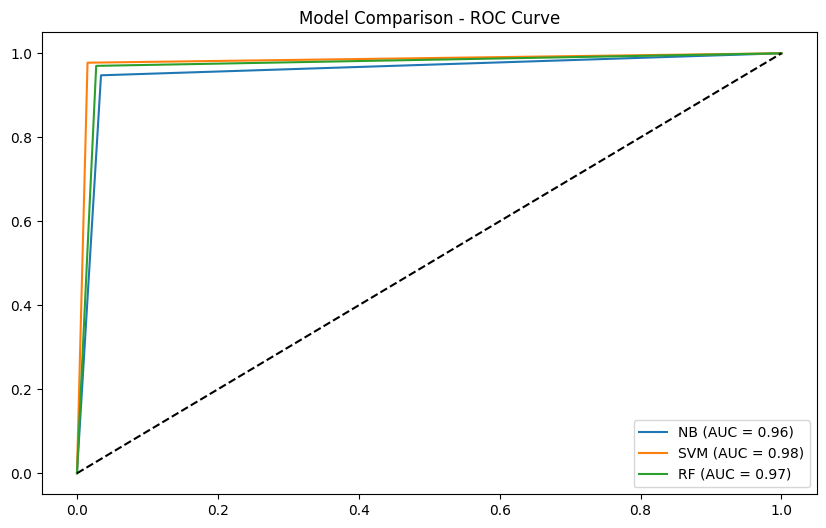

In [ ]:
#Model Comparison - ROC CURVE(Receiver Operating Characteristic Curve)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Example: Plotting ROC Curves for all three
plt.figure(figsize=(10,6))
for name, pred in [("NB", y_pred_nb), ("SVM", y_pred_svm), ("RF", y_pred_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Model Comparison - ROC Curve')
plt.legend()
plt.show()

In [ ]:
#Final Results
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Create table with all metrics
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'SVM', 'Random Forest'],

    'Accuracy': [
        acc_nb,
        acc_svm,
        acc_rf
    ],

    'Precision': [
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],

    'F1-Score': [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ]
})

# Sort by F1-Score (best metric for classification)
results = results.sort_values(by='F1-Score', ascending=False)

# Add Best column
results['Best'] = results['F1-Score'] == results['F1-Score'].max()

# Display styled table
results.style \
    .format({
        "Accuracy": "{:.2f}",
        "Precision": "{:.2f}",
        "Recall": "{:.2f}",
        "F1-Score": "{:.2f}"
    }) \
    .set_properties(**{
        'background-color': '#1e1e1e',
        'color': 'white',
        'border-color': 'gray'
    }) \
    .set_table_styles([
        {'selector': 'th',
         'props': [('background-color', '#111111'),
                   ('color', 'white'),
                   ('font-weight', 'bold')]}
    ])

,Model,Accuracy,Precision,Recall,F1-Score,Best
1,SVM,0.98,0.96,0.98,0.97,True
2,Random Forest,0.97,0.93,0.97,0.95,False
0,Naive Bayes,0.96,0.91,0.95,0.93,False
